# Clustering dei timbri (registri) delle note

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import sklearn
from sklearn.cluster import KMeans

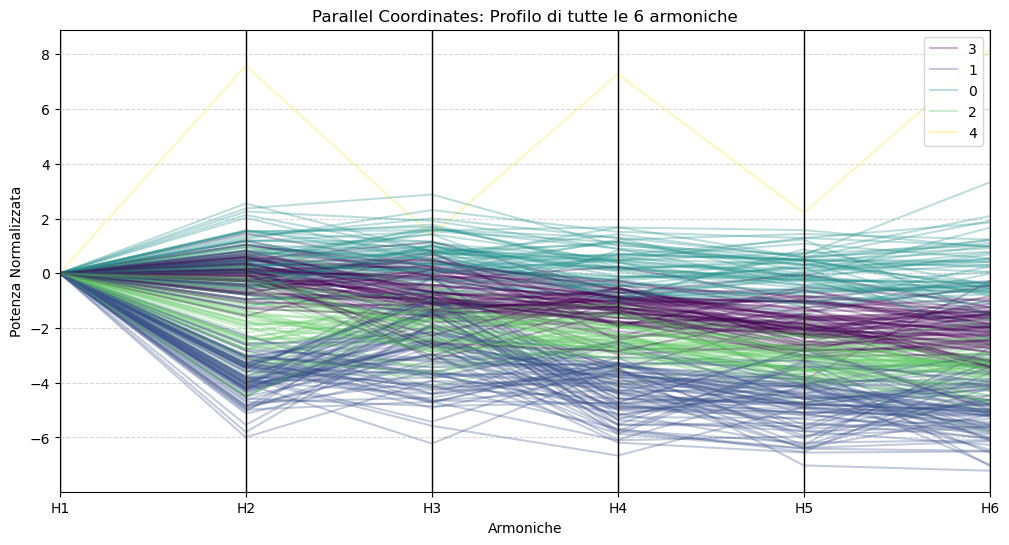

In [11]:
# qui facciamo il clustering con KMeans

# prendiamo i normalized power spectra
# e facciamo il clustering con KMeans

# carichiamo i dati che sono .csv
data = np.loadtxt('normalized_power_spectra.csv', delimiter=',')

# Usa solo le prime 6 colonne
data_6 = data[:, :6]  # seleziona solo le prime 6 colonne

# facciamo il clustering con KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(data_6)

columns = [f'H{i+1}' for i in range(6)]
df = pd.DataFrame(data_6, columns=columns)
df['Cluster'] = kmeans.labels_

plt.figure(figsize=(12, 6))
# Usiamo una trasparenza (alpha) bassa per gestire la sovrapposizione delle linee
parallel_coordinates(df, 'Cluster', colormap='viridis', alpha=0.3)

plt.title('Parallel Coordinates: Profilo di tutte le 6 armoniche')
plt.ylabel('Potenza Normalizzata')
plt.xlabel('Armoniche')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

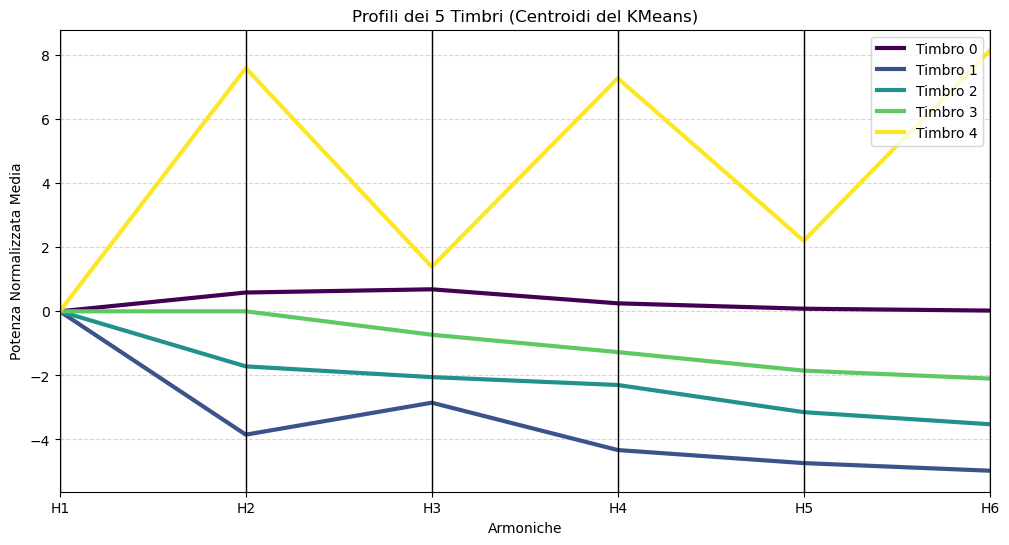

In [12]:
# 1. Estrai i centroidi dal modello K-Means
# Questa matrice avrà 5 righe (i cluster) e 6 colonne (le armoniche)
centroidi = kmeans.cluster_centers_

# 2. Crea le etichette per le colonne e per i cluster
columns = [f'H{i+1}' for i in range(6)]
df_centroidi = pd.DataFrame(centroidi, columns=columns)

# Diamo un nome ai 5 timbri
df_centroidi['Timbro'] = ['Timbro 0', 'Timbro 1', 'Timbro 2', 'Timbro 3', 'Timbro 4']

# 3. Plottiamo SOLO i centroidi
plt.figure(figsize=(12, 6))

# Non ci serve l'alpha qui, vogliamo linee belle marcate (linewidth=3)
parallel_coordinates(df_centroidi, 'Timbro', colormap='viridis', linewidth=3)

plt.title('Profili dei 5 Timbri (Centroidi del KMeans)')
plt.ylabel('Potenza Normalizzata Media')
plt.xlabel('Armoniche')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Cluster 0: 91 note vocali
Cluster 1: 60 note vocali
Cluster 2: 57 note vocali
Cluster 3: 67 note vocali
Cluster 4: 4 note vocali


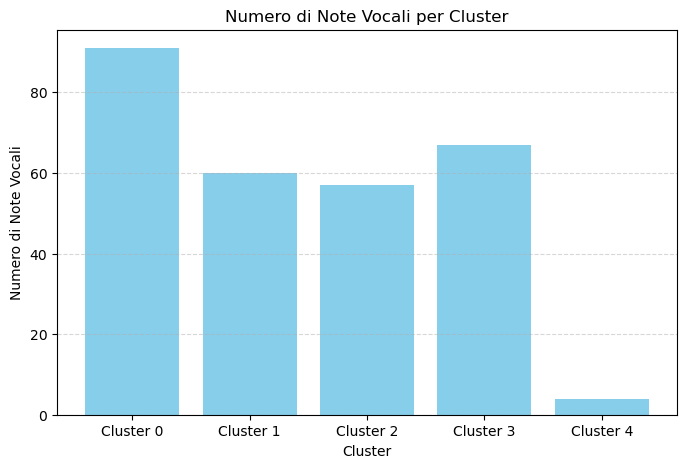

In [10]:
# Visualizza solo il numero di note vocali (fondamentali) per ogni cluster
note_vocali = np.loadtxt('fundamentals.csv')
counts = []
for cluster in range(5):
    n = np.sum(kmeans.labels_ == cluster)
    counts.append(n)
    print(f"Cluster {cluster}: {n} note vocali")

plt.figure(figsize=(8, 5))
plt.bar(range(5), counts, tick_label=[f'Cluster {i}' for i in range(5)], color='skyblue')
plt.title('Numero di Note Vocali per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Numero di Note Vocali')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()